# Sales Prediction Solution

This notebook contains the pipeline to predict store product sales using a custom stacked ensemble of gradient boosted trees, nearest neighbors, and extra trees models.

## 1. Setup & Imports

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb

try:
    from catboost import CatBoostRegressor, Pool
except ImportError:
    %pip install -q catboost
    from catboost import CatBoostRegressor, Pool

try:
    import optuna
except ImportError:
    %pip install -q optuna
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
DATA_DIR = '/content/drive/MyDrive/dsn-bootcamp-qualification-hackathon-2026-ml-track'

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.2 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Datasets

In [3]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

TARGET = 'total_sales'
id_col = 'id'

print(f"Train shape: {train.shape} | Test shape: {test.shape}")

Train shape: (6818, 13) | Test shape: (1705, 12)


In [4]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print('train shape:', train.shape)
print('test shape :', test.shape)
print('sample_submission shape:', sample_submission.shape)


train shape: (6818, 13)
test shape : (1705, 12)
sample_submission shape: (1705, 2)


## 3. Target & ID Identification

Determine the target column by diffing train vs test columns — never hard-code a guessed name.

In [5]:
target_candidates = [c for c in train.columns if c not in test.columns]
print('Target candidate(s):', target_candidates)
TARGET = target_candidates[0]

id_col = sample_submission.columns[0]
target_col_sub = sample_submission.columns[1]
print('ID column:', id_col, ' | submission target column:', target_col_sub)
assert target_col_sub == TARGET


Target candidate(s): ['total_sales']
ID column: id  | submission target column: total_sales


## 4. Data Inspection

In [6]:

print(train.dtypes)


id                      object
product_code            object
product_weight_kg      float64
fat_content             object
shelf_visibility       float64
product_category        object
product_price          float64
store_code              object
store_age_years          int64
store_size              object
store_location_tier     object
store_format            object
total_sales            float64
dtype: object


In [7]:
print('=== MISSING VALUES (train) ===')
print(train.isna().sum())
print()
print('=== MISSING VALUES (test) ===')
print(test.isna().sum())


=== MISSING VALUES (train) ===
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

=== MISSING VALUES (test) ===
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


In [8]:
print('Duplicated rows -> train:', train.duplicated().sum(), ' test:', test.duplicated().sum())
print('id unique -> train:', train[id_col].is_unique, ' test:', test[id_col].is_unique)


Duplicated rows -> train: 0  test: 0
id unique -> train: True  test: True


In [9]:
print('=== NUNIQUE per column ===')
for c in train.columns:
    print(f'{c:25s} {train[c].nunique()}')


=== NUNIQUE per column ===
id                        6818
product_code              1555
product_weight_kg         4675
fat_content               2
shelf_visibility          1732
product_category          48
product_price             5818
store_code                10
store_age_years           9
store_size                3
store_location_tier       3
store_format              4
total_sales               6776


## 5. Exploratory Data Analysis

### 5.1 Target distribution

In [10]:
y = train[TARGET]
print(y.describe())
print('skew:', y.skew())
print('kurtosis:', y.kurtosis())
print()
print('log1p skew:', np.log1p(y).skew())
print('sqrt  skew:', np.sqrt(y).skew())


count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64
skew: 1.1539947519138116
kurtosis: 1.5027484786109482

log1p skew: -0.8951280115081985
sqrt  skew: 0.2261573086657263


### 5.2 Categorical sanity checks



In [11]:
print('Raw product_category values:', sorted(train['product_category'].unique())[:10], '...')
print('Raw fat_content values:', train['fat_content'].unique())


Raw product_category values: ['BAKING GOODS', 'BREADS', 'BREAKFAST', 'Baking Goods', 'Breads', 'Breakfast', 'CANNED', 'Canned', 'DAIRY', 'Dairy'] ...
Raw fat_content values: ['Low Fat' 'Regular']


### 5.3 Numeric correlations with target

In [12]:
num_cols_raw = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']
for c in num_cols_raw:
    print(f'{c:20s} corr={train[c].corr(y):.3f}')


product_weight_kg    corr=0.016
shelf_visibility     corr=-0.118
product_price        corr=0.570
store_age_years      corr=0.039


### 5.4 Categorical group means



In [13]:
for c in ['store_format', 'store_size', 'store_location_tier']:
    print(train.groupby(c)[TARGET].agg(['mean', 'median', 'count']))
    print()


                             mean    median  count
store_format                                      
Corner Shop            336.353868   252.150    866
Flagship Hypermarket  3660.182219  3348.085    748
Standard Supermarket  2316.319677  1998.270   4462
Superstore            1971.661954  1622.170    742

                   mean    median  count
store_size                              
Large       2254.890120  1998.725    748
Medium      2670.506826  2242.365   2218
Small       1918.405954  1557.960   1933

                            mean   median  count
store_location_tier                             
Tier_1               1868.171278  1455.21   1909
Tier_2               2341.795296  2014.52   2232
Tier_3               2254.114400  1794.26   2677



### 5.5 Distribution and Relationship Visualizations



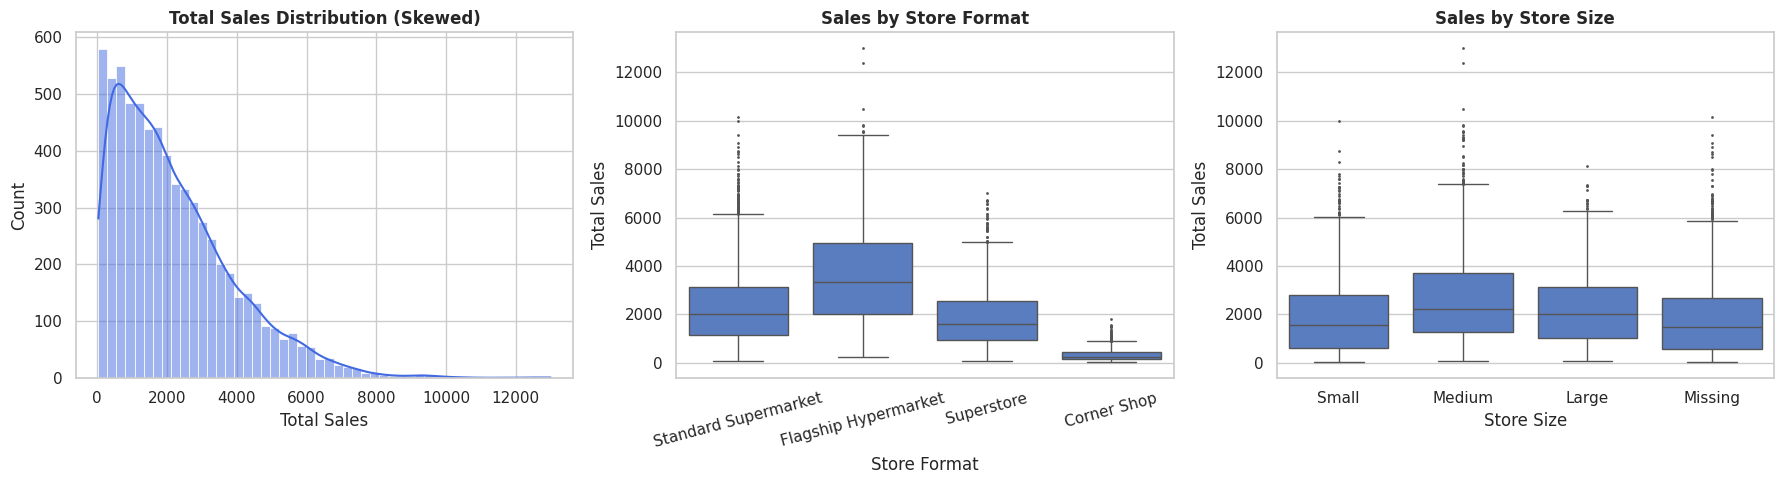

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Distribution (Total Sales)
sns.histplot(train[TARGET], bins=50, kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Total Sales Distribution (Skewed)", fontsize=12, fontweight="semibold")
axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("Count")

# 2. Sales by Store Format
sns.boxplot(x="store_format", y=TARGET, data=train, ax=axes[1], fliersize=1)
axes[1].set_title("Sales by Store Format", fontsize=12, fontweight="semibold")
axes[1].set_xlabel("Store Format")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis="x", rotation=15)

# 3. Sales by Store Size
sns.boxplot(x="store_size", y=TARGET, data=train.fillna({"store_size": "Missing"}), ax=axes[2], order=["Small", "Medium", "Large", "Missing"], fliersize=1)
axes[2].set_title("Sales by Store Size", fontsize=12, fontweight="semibold")
axes[2].set_xlabel("Store Size")
axes[2].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

### 5.6 Numeric Relationships & Correlation Matrix

Let's visualize how our key continuous features interact with the target, beginning with a scatter plot of Product Price versus Total Sales, and concluding with a correlation matrix heatmap of our primary numerical attributes.

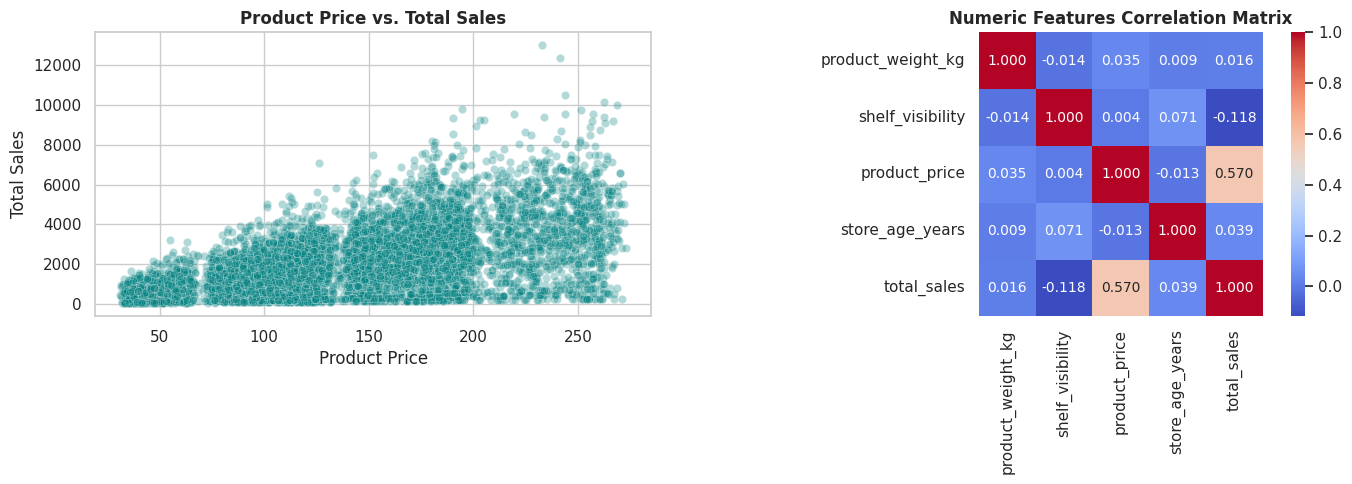

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Numeric Relationships & Correlation Matrix ---
# This cell generates two plots to understand the interaction between numerical features
# and the target variable, as well as their inter-correlations.

# Set up the figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Product Price vs. Total Sales (Scatter Plot)
# This plot helps to visually inspect the direct relationship between product price and total sales.
# Alpha is used to show density in overlapping points.
sns.scatterplot(data=train, x='product_price', y=TARGET, alpha=0.3, color='teal', ax=axes[0])
axes[0].set_title('Product Price vs. Total Sales', fontsize=12, fontweight='semibold')
axes[0].set_xlabel('Product Price')
axes[0].set_ylabel('Total Sales')

# Plot 2: Correlation Matrix of Numeric Attributes (Heatmap)
# This heatmap displays the Pearson correlation coefficients between selected numerical features and the target.
# It helps identify the strength and direction of linear relationships.
# 'num_cols_raw' is assumed to be defined earlier in the notebook.
corr_matrix = train[num_cols_raw + [TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', square=True, cbar=True, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Numeric Features Correlation Matrix', fontsize=12, fontweight='semibold')

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
# Display the plots
plt.show()

In [ ]:
print('Weight missing in train:', train['product_weight_kg'].isna().sum())
full_ref = pd.concat([train[['product_code', 'product_weight_kg']],
                      test[['product_code', 'product_weight_kg']]], axis=0)
weight_map = full_ref.dropna().groupby('product_code')['product_weight_kg'].mean()
missing_codes = train.loc[train['product_weight_kg'].isna(), 'product_code']
print('Recoverable via other rows of the same product:',
      missing_codes.isin(weight_map.index).sum(), '/', len(missing_codes))
print()
print('store_size missing rows are missing for whole stores, not randomly:')
print(train.groupby('store_code')['store_size'].apply(lambda s: s.isna().all() or s.notna().all()))


Weight missing in train: 1225
Recoverable via other rows of the same product: 1223 / 1225

store_size missing rows are missing for whole stores, not randomly:
store_code
STORE-7WS    True
STORE-89Z    True
STORE-9RG    True
STORE-AGY    True
STORE-DKU    True
STORE-HL7    True
STORE-JOR    True
STORE-OYG    True
STORE-T5G    True
STORE-YLW    True
Name: store_size, dtype: bool


In [ ]:
train_key = set(zip(train['product_code'], train['store_code']))
test_key = set(zip(test['product_code'], test['store_code']))
print('Overlapping (product, store) combos between train & test:', len(train_key & test_key))
print('=> confirms plain random K-Fold CV is appropriate (no group/time leakage risk).')


Overlapping (product, store) combos between train & test: 0
=> confirms plain random K-Fold CV is appropriate (no group/time leakage risk).


### Preprocessing & Engineering Functions

In [ ]:
CAT_COLS = [
    'fat_content', 'product_category', 'store_code', 'store_size',
    'store_location_tier', 'store_format', 'store_age_bucket',
    'category_x_format', 'category_x_size', 'format_x_size', 'format_x_tier',
    'price_bucket'
]

NUM_COLS_BASE = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']
ENGINEERED_NUM = [
    'price_per_kg', 'visibility_ratio_to_category', 'visibility_was_zero',
    'is_corner_shop', 'product_popularity', 'price_rank_in_category'
]

def clean_and_prepare_data(train_df, test_df):
    df_tr = train_df.copy()
    df_te = test_df.copy()

    # Normalize string casing issues
    for df in (df_tr, df_te):
        df['product_category'] = df['product_category'].str.strip().str.lower()
        df['fat_content'] = df['fat_content'].str.strip().str.title()

    # Fill missing product weights
    combined_weights = pd.concat([df_tr[['product_code', 'product_weight_kg']], df_te[['product_code', 'product_weight_kg']]])
    weight_lookup = combined_weights.dropna().groupby('product_code')['product_weight_kg'].mean()
    global_weight_median = combined_weights['product_weight_kg'].median()

    for df in (df_tr, df_te):
        missing_w = df['product_weight_kg'].isna()
        df.loc[missing_w, 'product_weight_kg'] = df.loc[missing_w, 'product_code'].map(weight_lookup)
        df['product_weight_kg'] = df['product_weight_kg'].fillna(global_weight_median)

    # Fix shelf visibility zeroes
    combined_vis = pd.concat([df_tr[['product_category', 'shelf_visibility']], df_te[['product_category', 'shelf_visibility']]])
    combined_vis = combined_vis.replace({'shelf_visibility': {0: np.nan}})
    visibility_lookup = combined_vis.groupby('product_category')['shelf_visibility'].mean()

    for df in (df_tr, df_te):
        df['visibility_was_zero'] = (df['shelf_visibility'] == 0).astype(int)
        df.loc[df['shelf_visibility'] == 0, 'shelf_visibility'] = np.nan
        df['shelf_visibility'] = df['shelf_visibility'].fillna(df['product_category'].map(visibility_lookup))
        df['visibility_ratio_to_category'] = df['shelf_visibility'] / df['product_category'].map(visibility_lookup)

    # Structural features
    for df in (df_tr, df_te):
        df['store_size'] = df['store_size'].fillna('Missing')
        df['store_age_bucket'] = pd.cut(df['store_age_years'], bins=[0, 25, 30, 35, 50], labels=['new', 'mid', 'mature', 'old']).astype(str)
        df['price_per_kg'] = df['product_price'] / df['product_weight_kg'].replace(0, np.nan)
        df['price_per_kg'] = df['price_per_kg'].fillna(df['price_per_kg'].median())

        # Cross-categorical features
        df['category_x_format'] = df['product_category'].astype(str) + '_' + df['store_format'].astype(str)
        df['category_x_size'] = df['product_category'].astype(str) + '_' + df['store_size'].astype(str)
        df['format_x_size'] = df['store_format'].astype(str) + '_' + df['store_size'].astype(str)
        df['format_x_tier'] = df['store_format'].astype(str) + '_' + df['store_location_tier'].astype(str)
        df['is_corner_shop'] = (df['store_format'] == 'Corner Shop').astype(int)

    # Price quantiles
    _, bins = pd.qcut(df_tr['product_price'], q=10, labels=False, duplicates='drop', retbins=True)
    bins = bins.copy()
    bins[0], bins[-1] = -np.inf, np.inf
    df_tr['price_bucket'] = pd.cut(df_tr['product_price'], bins=bins, labels=False).astype(str)
    df_te['price_bucket'] = pd.cut(df_te['product_price'], bins=bins, labels=False).astype(str)

    # Listing counts and percentiles
    combined_codes = pd.concat([df_tr[['product_code']], df_te[['product_code']]])
    popularity_lookup = combined_codes['product_code'].value_counts()

    combined_prices = pd.concat([df_tr[['product_category', 'product_price']], df_te[['product_category', 'product_price']]])
    combined_prices['price_rank_in_category'] = combined_prices.groupby('product_category')['product_price'].rank(pct=True)

    n_train = len(df_tr)
    df_tr['product_popularity'] = df_tr['product_code'].map(popularity_lookup).fillna(1)
    df_te['product_popularity'] = df_te['product_code'].map(popularity_lookup).fillna(1)

    df_tr['price_rank_in_category'] = combined_prices['price_rank_in_category'].iloc[:n_train].values
    df_te['price_rank_in_category'] = combined_prices['price_rank_in_category'].iloc[n_train:].values

    return df_tr, df_te

train_clean, test_clean = clean_and_prepare_data(train, test)

### Target Encoding & Encoding Pipelines

In [ ]:
def target_encode(train_col, y, test_col, n_splits=5, seed=42, smoothing=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(train_col))
    global_mean = y.mean()

    train_col = train_col.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    for tr_idx, val_idx in kf.split(train_col):
        tr_x, tr_y = train_col.iloc[tr_idx], y.iloc[tr_idx]
        stats = tr_y.groupby(tr_x).agg(['mean', 'count'])
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        oof[val_idx] = train_col.iloc[val_idx].map(smoothed).fillna(global_mean).values

    stats_full = y.groupby(train_col).agg(['mean', 'count'])
    smoothed_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
    test_encoded = test_col.map(smoothed_full).fillna(global_mean).values
    return oof, test_encoded

def encode_dataframes(tr, te, target_y):
    tr, te = tr.copy(), te.copy()

    # Ordinal mapping for categoricals
    for c in CAT_COLS:
        mapped_cats = pd.Categorical(tr[c].astype(str))
        mapping = {v: i for i, v in enumerate(mapped_cats.categories)}
        tr[c + '_oe'] = tr[c].astype(str).map(mapping)
        te[c + '_oe'] = te[c].astype(str).map(mapping).fillna(-1)

    oof_te, test_te = target_encode(tr['product_code'], target_y, te['product_code'])
    tr['product_code_te'] = oof_te
    te['product_code_te'] = test_te

    freq = tr['product_code'].value_counts()
    tr['product_code_freq'] = tr['product_code'].map(freq)
    te['product_code_freq'] = te['product_code'].map(freq).fillna(0)

    return tr, te

### Build Features

In [ ]:
y_raw = train_clean[TARGET].values
train_fe, test_fe = encode_dataframes(train_clean, test_clean, y_raw)

# Standard models feature subset
model_cat_cols = [c + '_oe' for c in CAT_COLS]
feat_cols = NUM_COLS_BASE + ENGINEERED_NUM + model_cat_cols + ['product_code_te', 'product_code_freq']
X = train_fe[feat_cols].reset_index(drop=True)

# CatBoost categorical representation
cb_feat_cols = [
    'product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',
    'price_per_kg', 'visibility_ratio_to_category', 'visibility_was_zero', 'is_corner_shop',
    'product_popularity', 'price_rank_in_category', 'product_code_te', 'product_code_freq'
] + CAT_COLS

X_cb = train_clean.copy()

# Add target encodings to CB set manually
X_cb['product_code_te'] = train_fe['product_code_te']
X_cb['product_code_freq'] = train_fe['product_code_freq']
X_cb = X_cb[cb_feat_cols].reset_index(drop=True)

for c in CAT_COLS:
    X_cb[c] = X_cb[c].astype(str)
cat_idx = [X_cb.columns.get_loc(c) for c in CAT_COLS]

In [ ]:
# Cross-validation baseline score tracking
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
scores_baseline = {}

def eval_sklearn_regressor(name, get_model, X_train, y_train):
    scores = []
    for tr_idx, val_idx in kf.split(X_train):
        model = get_model()
        model.fit(X_train.iloc[tr_idx], y_train[tr_idx])
        scores.append(rmse(y_train[val_idx], model.predict(X_train.iloc[val_idx])))
    scores_baseline[name] = (np.mean(scores), np.std(scores))
    print(f"{name:<16} | Mean CV RMSE: {np.mean(scores):.3f} (Std: {np.std(scores):.3f})")

eval_sklearn_regressor('Ridge', lambda: Ridge(alpha=1.0, random_state=SEED), X, y_raw)
eval_sklearn_regressor('RandomForest', lambda: RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=15, random_state=SEED, n_jobs=-1), X, y_raw)
eval_sklearn_regressor('ExtraTrees', lambda: ExtraTreesRegressor(n_estimators=400, max_depth=10, min_samples_leaf=10, random_state=SEED, n_jobs=-1), X, y_raw)
eval_sklearn_regressor('HistGB', lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=6, random_state=SEED), X, y_raw)

Ridge            | Mean CV RMSE: 1128.297 (Std: 21.257)
RandomForest     | Mean CV RMSE: 1082.868 (Std: 19.599)
ExtraTrees       | Mean CV RMSE: 1087.623 (Std: 17.116)
HistGB           | Mean CV RMSE: 1097.379 (Std: 20.053)


In [ ]:
# LightGBM validation baseline
lgb_scores = []
for tr_idx, val_idx in kf.split(X):
    model = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.03, num_leaves=31,
                              subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbosity=-1)
    model.fit(X.iloc[tr_idx], y_raw[tr_idx], eval_set=[(X.iloc[val_idx], y_raw[val_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    lgb_scores.append(rmse(y_raw[val_idx], model.predict(X.iloc[val_idx])))
scores_baseline['LightGBM'] = (np.mean(lgb_scores), np.std(lgb_scores))
print(f"LightGBM         | Mean CV RMSE: {np.mean(lgb_scores):.3f} (Std: {np.std(lgb_scores):.3f})")

LightGBM         | Mean CV RMSE: 1087.069 (Std: 18.439)


In [ ]:
# XGBoost validation baseline
xgb_scores = []
for tr_idx, val_idx in kf.split(X):
    model = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.03, max_depth=5,
                             subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                             early_stopping_rounds=100, verbosity=0)
    model.fit(X.iloc[tr_idx], y_raw[tr_idx], eval_set=[(X.iloc[val_idx], y_raw[val_idx])], verbose=False)
    xgb_scores.append(rmse(y_raw[val_idx], model.predict(X.iloc[val_idx])))
scores_baseline['XGBoost'] = (np.mean(xgb_scores), np.std(xgb_scores))
print(f"XGBoost          | Mean CV RMSE: {np.mean(xgb_scores):.3f} (Std: {np.std(xgb_scores):.3f})")

XGBoost          | Mean CV RMSE: 1081.119 (Std: 22.652)


In [ ]:
# CatBoost validation baseline (native categorical features)
cb_scores = []
for tr_idx, val_idx in kf.split(X_cb):
    pool_tr = Pool(X_cb.iloc[tr_idx], y_raw[tr_idx], cat_features=cat_idx)
    pool_val = Pool(X_cb.iloc[val_idx], y_raw[val_idx], cat_features=cat_idx)
    model = CatBoostRegressor(iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
                              random_seed=SEED, verbose=False, early_stopping_rounds=100, loss_function='RMSE')
    model.fit(pool_tr, eval_set=pool_val, use_best_model=True)
    cb_scores.append(rmse(y_raw[val_idx], model.predict(X_cb.iloc[val_idx])))
scores_baseline['CatBoost'] = (np.mean(cb_scores), np.std(cb_scores))
print(f"CatBoost         | Mean CV RMSE: {np.mean(cb_scores):.3f} (Std: {np.std(cb_scores):.3f})")

CatBoost         | Mean CV RMSE: 1076.343 (Std: 19.982)


In [ ]:
print("=== Model Cross-Validation Leaderboard ===")
for name, (mean_err, std_err) in sorted(scores_baseline.items(), key=lambda item: item[1][0]):
    print(f"{name:<16} : Mean RMSE = {mean_err:.2f} (Std: {std_err:.2f})")

=== Model Cross-Validation Leaderboard ===
CatBoost         : Mean RMSE = 1076.34 (Std: 19.98)
XGBoost          : Mean RMSE = 1081.12 (Std: 22.65)
RandomForest     : Mean RMSE = 1082.87 (Std: 19.60)
LightGBM         : Mean RMSE = 1087.07 (Std: 18.44)
ExtraTrees       : Mean RMSE = 1087.62 (Std: 17.12)
HistGB           : Mean RMSE = 1097.38 (Std: 20.05)
Ridge            : Mean RMSE = 1128.30 (Std: 21.26)


### Target Transform Analysis
Checking raw scale performance vs. common numeric stabilization transformations.

In [ ]:
# Checking alternative response transformations
for label, forward_fn, inverse_fn in [
    ('raw', lambda x: x, lambda x: x),
    ('log1p', np.log1p, np.expm1),
    ('sqrt', np.sqrt, lambda x: x ** 2)
]:
    transform_scores = []
    for tr_idx, val_idx in kf.split(X_cb):
        y_tr, y_val = y_raw[tr_idx], y_raw[val_idx]
        pool_tr = Pool(X_cb.iloc[tr_idx], forward_fn(y_tr), cat_features=cat_idx)
        pool_val = Pool(X_cb.iloc[val_idx], forward_fn(y_val), cat_features=cat_idx)
        model = CatBoostRegressor(iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
                                  random_seed=SEED, verbose=False, early_stopping_rounds=100)
        model.fit(pool_tr, eval_set=pool_val, use_best_model=True)
        predictions = inverse_fn(model.predict(X_cb.iloc[val_idx]))
        transform_scores.append(rmse(y_val, predictions))
    print(f"{label:<6} transform -> Mean CV RMSE: {np.mean(transform_scores):.3f}")

raw    transform -> Mean CV RMSE: 1076.343
log1p  transform -> Mean CV RMSE: 1102.840
sqrt   transform -> Mean CV RMSE: 1082.002


### Hyperparameter Configurations

In [ ]:
BEST_CATBOOST_PARAMS = {
    'depth': 4,
    'learning_rate': 0.02150173026890165,
    'l2_leaf_reg': 1.5967851649577447,
    'random_strength': 0.4471518598829618,
    'bagging_temperature': 0.6519382562286391,
    'border_count': 128,
    'max_ctr_complexity': 1,
    'grow_policy': 'Depthwise'
}

BEST_XGB_PARAMS = {
    'learning_rate': 0.019292008104701542,
    'max_depth': 3,
    'subsample': 0.6489034629666132,
    'colsample_bytree': 0.5653367596938141,
    'reg_alpha': 0.13675720684420165,
    'reg_lambda': 0.01828628495750791,
    'min_child_weight': 20,
    'gamma': 0.036974474075762404,
    'tree_method': 'exact'
}

BEST_LGB_PARAMS = {
    'learning_rate': 0.026059925572509055,
    'num_leaves': 9,
    'min_child_samples': 37,
    'subsample': 0.8303964472237759,
    'colsample_bytree': 0.8477507398556255,
    'reg_alpha': 1.4792508696416802,
    'reg_lambda': 0.14801271501897767,
    'min_split_gain': 0.01052747079864985
}

### Hyperparameter Optimization Framework


In [ ]:
def tune_catboost(X_train, y_train, cat_indices, n_trials=18, tune_folds=3):
    kf_tune = KFold(n_splits=tune_folds, shuffle=True, random_state=SEED)
    splits = list(kf_tune.split(X_train))

    def objective(trial):
        params = {
            'iterations': 1000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
            'depth': trial.suggest_int('depth', 4, 6),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.0, 3.0),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
            'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
            'max_ctr_complexity': 1,
            'grow_policy': 'Depthwise',
            'loss_function': 'RMSE',
            'random_seed': SEED,
            'verbose': False,
            'early_stopping_rounds': 60,
            'thread_count': -1
        }
        val_scores = []
        for tr_idx, val_idx in splits:
            pool_tr = Pool(X_train.iloc[tr_idx], y_train[tr_idx], cat_features=cat_indices)
            pool_val = Pool(X_train.iloc[val_idx], y_train[val_idx], cat_features=cat_indices)
            model = CatBoostRegressor(**params)
            model.fit(pool_tr, eval_set=pool_val, use_best_model=True)
            val_scores.append(rmse(y_train[val_idx], model.predict(X_train.iloc[val_idx])))
        return float(np.mean(val_scores))

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)
    return study

In [ ]:
def tune_extratrees(X_train, y_train, n_trials=18, tune_folds=3):
    kf_tune = KFold(n_splits=tune_folds, shuffle=True, random_state=SEED)
    splits = list(kf_tune.split(X_train))

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
            'max_features': trial.suggest_float('max_features', 0.5, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': SEED,
            'n_jobs': -1
        }
        val_scores = []
        for tr_idx, val_idx in splits:
            model = ExtraTreesRegressor(**params)
            model.fit(X_train.iloc[tr_idx], y_train[tr_idx])
            val_scores.append(rmse(y_train[val_idx], model.predict(X_train.iloc[val_idx])))
        return float(np.mean(val_scores))

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)
    return study

### Model Tuning & Execution

In [ ]:
# ExtraTrees parameter search
study_et = tune_extratrees(X, y_raw, n_trials=100, tune_folds=3)
BEST_EXTRATREES_PARAMS = study_et.best_params
print(f"Best ExtraTrees RMSE: {study_et.best_value:.4f}")

Best ExtraTrees RMSE: 1077.1007


In [ ]:
# CatBoost parameter search
study_cb = tune_catboost(X_cb, y_raw, cat_idx, n_trials=50, tune_folds=3)
BEST_CATBOOST_PARAMS = study_cb.best_params
print(f"Best CatBoost RMSE: {study_cb.best_value:.4f}")

Best CatBoost RMSE: 1075.6059


### Validation & Leakage Auditing

In [ ]:
# Verify train-test alignment & target mapping properties
assert train_clean.duplicated().sum() == 0, "Duplicate rows detected in training set"
overlap_count = len(set(zip(train_clean.product_code, train_clean.store_code)) & set(zip(test_clean.product_code, test_clean.store_code)))
print(f"Overlap key combinations: {overlap_count}")

# Run diagnostic folds to generate out-of-fold predictions
diag_predictions = np.zeros(len(X_cb))
for tr_idx, val_idx in kf.split(X_cb):
    pool_tr = Pool(X_cb.iloc[tr_idx], y_raw[tr_idx], cat_features=cat_idx)
    pool_val = Pool(X_cb.iloc[val_idx], y_raw[val_idx], cat_features=cat_idx)
    model = CatBoostRegressor(iterations=3000, loss_function='RMSE', random_seed=SEED, verbose=False,
                              early_stopping_rounds=150, thread_count=-1, **BEST_CATBOOST_PARAMS)
    model.fit(pool_tr, eval_set=pool_val, use_best_model=True)
    diag_predictions[val_idx] = model.predict(X_cb.iloc[val_idx])

diagnostics_df = train.copy()
diagnostics_df['pred'] = diag_predictions
diagnostics_df['abs_error'] = np.abs(diagnostics_df[TARGET] - diagnostics_df['pred'])
diagnostics_df['units_implied'] = diagnostics_df[TARGET] / diagnostics_df['product_price']

print("\n--- Top 10 Absolute Prediction Errors ---")
print(diagnostics_df.sort_values('abs_error', ascending=False)[['product_code', 'store_code', 'product_price', TARGET, 'pred', 'units_implied']].head(10))

Overlap key combinations: 0

--- Top 10 Absolute Prediction Errors ---
     product_code store_code  product_price  total_sales         pred  \
5404   PRD-I67HN3  STORE-7WS         232.78     12996.82  5533.523822   
4220   PRD-5I78U5  STORE-7WS         241.26     12359.04  5838.596785   
900    PRD-PUWBWJ  STORE-OYG         262.30     10130.90  4166.192790   
5950   PRD-LV9PLM  STORE-YLW         268.58      9999.51  4075.691952   
1555   PRD-B9OF3M  STORE-DKU         262.55      9388.15  3998.188970   
625    PRD-YW8YG4  STORE-OYG         255.71      8894.14  3791.174327   
3444   PRD-N5F3DX  STORE-OYG         224.71      8617.32  3543.058881   
4511   PRD-07NNDG  STORE-DKU         262.86      9072.04  4029.777784   
4363   PRD-6YLBXP  STORE-7WS         258.91      1377.26  6300.630228   
235    PRD-WFA6ZI  STORE-7WS         243.69     10477.97  5568.798613   

      units_implied  
5404      55.833061  
4220      51.227058  
900       38.623332  
5950      37.231030  
1555      35.75

### Final Stacked Repeated-CV Bagging Ensemble

In [ ]:
# Multi-seed cross validation bagger
seeds = [1, 7, 99, 123, 2024]
num_folds = 5

x_test_df = test_fe[feat_cols].reset_index(drop=True)

# Correctly align test feature mapping for CatBoost from test_clean and test_fe
x_test_cb_df = test_clean.copy()
x_test_cb_df['product_code_te'] = test_fe['product_code_te']
x_test_cb_df['product_code_freq'] = test_fe['product_code_freq']
x_test_cb_df = x_test_cb_df[cb_feat_cols].reset_index(drop=True)

for col in CAT_COLS:
    x_test_cb_df[col] = x_test_cb_df[col].astype(str)

n_train, n_test = len(X), len(x_test_df)

oof_preds = {m: np.zeros(n_train) for m in ['cb', 'xgb', 'lgb', 'hgb', 'knn', 'et']}
oof_counts = {m: np.zeros(n_train) for m in ['cb', 'xgb', 'lgb', 'hgb', 'knn', 'et']}
test_preds = {m: np.zeros(n_test) for m in ['cb', 'xgb', 'lgb', 'hgb', 'knn', 'et']}
total_iterations = 0

tr_start = time.time()
for r_idx, seed_val in enumerate(seeds):
    kf_rep = KFold(n_splits=num_folds, shuffle=True, random_state=seed_val)
    for fold_idx, (tr_idx, val_idx) in enumerate(kf_rep.split(X)):
        y_tr, y_val = y_raw[tr_idx], y_raw[val_idx]

        # 1. CatBoost
        cb_model = CatBoostRegressor(iterations=3000, loss_function='RMSE', random_seed=seed_val, verbose=False,
                                     early_stopping_rounds=150, thread_count=-1, **BEST_CATBOOST_PARAMS)
        cb_model.fit(Pool(X_cb.iloc[tr_idx], y_tr, cat_features=cat_idx),
                     eval_set=Pool(X_cb.iloc[val_idx], y_val, cat_features=cat_idx), use_best_model=True)
        oof_preds['cb'][val_idx] += cb_model.predict(X_cb.iloc[val_idx])
        oof_counts['cb'][val_idx] += 1
        test_preds['cb'] += cb_model.predict(x_test_cb_df)

        # 2. XGBoost
        xgb_model = xgb.XGBRegressor(n_estimators=3000, random_state=seed_val, early_stopping_rounds=150,
                                     verbosity=0, n_jobs=-1, **BEST_XGB_PARAMS)
        xgb_model.fit(X.iloc[tr_idx], y_tr, eval_set=[(X.iloc[val_idx], y_val)], verbose=False)
        oof_preds['xgb'][val_idx] += xgb_model.predict(X.iloc[val_idx])
        oof_counts['xgb'][val_idx] += 1
        test_preds['xgb'] += xgb_model.predict(x_test_df)

        # 3. LightGBM
        lgb_model = lgb.LGBMRegressor(n_estimators=3000, random_state=seed_val, verbosity=-1, n_jobs=-1, **BEST_LGB_PARAMS)
        lgb_model.fit(X.iloc[tr_idx], y_tr, eval_set=[(X.iloc[val_idx], y_val)], callbacks=[lgb.early_stopping(150, verbose=False)])
        oof_preds['lgb'][val_idx] += lgb_model.predict(X.iloc[val_idx])
        oof_counts['lgb'][val_idx] += 1
        test_preds['lgb'] += lgb_model.predict(x_test_df)

        # 4. HistGradientBoosting
        hgb_model = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.04, max_depth=5,
                                                   l2_regularization=1.0, random_state=seed_val)
        hgb_model.fit(X.iloc[tr_idx], y_tr)
        oof_preds['hgb'][val_idx] += hgb_model.predict(X.iloc[val_idx])
        oof_counts['hgb'][val_idx] += 1
        test_preds['hgb'] += hgb_model.predict(x_test_df)

        # 5. KNeighbors
        scaler = StandardScaler()
        xs_tr = scaler.fit_transform(X.iloc[tr_idx])
        xs_val = scaler.transform(X.iloc[val_idx])
        xs_te = scaler.transform(x_test_df)
        knn_model = KNeighborsRegressor(n_neighbors=15, weights='distance')
        knn_model.fit(xs_tr, y_tr)
        oof_preds['knn'][val_idx] += knn_model.predict(xs_val)
        oof_counts['knn'][val_idx] += 1
        test_preds['knn'] += knn_model.predict(xs_te)

        # 6. ExtraTrees
        et_model = ExtraTreesRegressor(random_state=seed_val, n_jobs=-1, **BEST_EXTRATREES_PARAMS)
        et_model.fit(X.iloc[tr_idx], y_tr)
        oof_preds['et'][val_idx] += et_model.predict(X.iloc[val_idx])
        oof_counts['et'][val_idx] += 1
        test_preds['et'] += et_model.predict(x_test_df)

        total_iterations += 1

    print(f"Seed group {r_idx+1}/{len(seeds)} training complete. (Runtime: {time.time()-tr_start:.1f}s)")

oof_final = {k: oof_preds[k] / oof_counts[k] for k in oof_preds}
test_avg = {k: test_preds[k] / total_iterations for k in test_preds}

print()
for model_key in ['cb', 'xgb', 'lgb', 'hgb', 'knn', 'et']:
    print(f"Out-Of-Fold RMSE ({model_key}) : {rmse(y_raw, oof_final[model_key]):.3f}")

Seed group 1/5 training complete. (Runtime: 50.8s)
Seed group 2/5 training complete. (Runtime: 95.9s)
Seed group 3/5 training complete. (Runtime: 145.9s)
Seed group 4/5 training complete. (Runtime: 203.3s)
Seed group 5/5 training complete. (Runtime: 255.9s)

Out-Of-Fold RMSE (cb) : 1072.973
Out-Of-Fold RMSE (xgb) : 1072.536
Out-Of-Fold RMSE (lgb) : 1072.149
Out-Of-Fold RMSE (hgb) : 1085.520
Out-Of-Fold RMSE (knn) : 1113.022
Out-Of-Fold RMSE (et) : 1073.784


### Linear Stacking Model Formulation

In [ ]:
# Ordinary Least Squares meta-learner mapping of submodel outputs
A_stack = np.vstack([oof_final['cb'], oof_final['xgb'], oof_final['lgb'], oof_final['hgb'], oof_final['knn'], oof_final['et'], np.ones(n_train)]).T
stack_weights, *_ = np.linalg.lstsq(A_stack, y_raw, rcond=None)
stacked_oof_preds = A_stack @ stack_weights

print("Optimized stacking weights (including bias term):")
print(stack_weights)
print(f"\nStacked Out-of-Fold Repeated-CV RMSE: {rmse(y_raw, stacked_oof_preds):.4f}")

Optimized stacking weights (including bias term):
[ 1.52396603e-01  2.15178999e-01  3.88216824e-01  1.02058475e-02
  6.73740745e-02  1.94481440e-01 -5.86624507e+01]

Stacked Out-of-Fold Repeated-CV RMSE: 1070.2072


### Validation Performance Leaderboard

In [ ]:
# Compare cross-validation baselines directly with tuned stack representations
summary_data = {
    'Model Configuration': [
        'Baseline Ridge',
        'Baseline RandomForest',
        'Baseline ExtraTrees',
        'Baseline HistGB',
        'Baseline LightGBM',
        'Baseline XGBoost',
        'Baseline CatBoost',
        'Optimized Extra Trees',
        'Optimized Bagged Stack'
    ],
    'CV RMSE Score': [
        scores_baseline.get('Ridge', (np.nan,))[0],
        scores_baseline.get('RandomForest', (np.nan,))[0],
        scores_baseline.get('ExtraTrees', (np.nan,))[0],
        scores_baseline.get('HistGB', (np.nan,))[0],
        scores_baseline.get('LightGBM', (np.nan,))[0],
        scores_baseline.get('XGBoost', (np.nan,))[0],
        scores_baseline.get('CatBoost', (np.nan,))[0],
        rmse(y_raw, oof_final['et']),
        rmse(y_raw, stacked_oof_preds)
    ]
}
print(pd.DataFrame(summary_data).to_string(index=False))

   Model Configuration  CV RMSE Score
        Baseline Ridge    1128.296839
 Baseline RandomForest    1082.867509
   Baseline ExtraTrees    1087.622764
       Baseline HistGB    1097.379045
     Baseline LightGBM    1087.068744
      Baseline XGBoost    1081.118974
     Baseline CatBoost    1076.343295
 Optimized Extra Trees    1073.784410
Optimized Bagged Stack    1070.207202


## 14. Final Submission

Generate test predictions from the bagged model averages, apply the stacking
weights, clip at zero (sales cannot be negative), and write to the exact
format required by `sample_submission.csv`.

In [ ]:
A_test = np.vstack([test_avg['cb'], test_avg['xgb'], test_avg['lgb'], test_avg['hgb'], test_avg['knn'], test_avg['et'],
                     np.ones(n_test)]).T
final_pred = A_test @ stack_weights
final_pred = np.clip(final_pred, 0, None)

submission = pd.DataFrame({
    id_col: test[id_col].values,
    TARGET: final_pred
})

assert len(submission) == len(test)
assert submission[TARGET].notna().all()
assert list(submission.columns) == list(sub.columns)

submission.to_csv('new_submission.csv', index=False)
print('Saved new submission.csv')

Saved new submission.csv


In [ ]:
A_test = np.vstack([test_avg['cb'], test_avg['xgb'], test_avg['lgb'], test_avg['hgb'], test_avg['knn'], test_avg['et'], np.ones(n_test)]).T
final_pred = A_test @ stack_weights
final_pred = np.clip(final_pred, 0, None)

submission = pd.DataFrame({
    id_col: test[id_col].values,
    TARGET: final_pred
})

# Save with standard competition name as well as new_submission
submission.to_csv('submission.csv', index=False)
submission.to_csv('new_submission.csv', index=False)
print('Submission file saved successfully as submission.csv and new_submission.csv.')

Submission file saved successfully as submission.csv and new_submission.csv.


### 14.1 Submission Verification

In [ ]:
print('Submission shape:', submission.shape)
print('Columns:', list(submission.columns))
print('Missing predictions:', submission[TARGET].isna().sum())
print('Minimum prediction:', submission[TARGET].min())
print('Maximum prediction:', submission[TARGET].max())
print('Mean prediction:', submission[TARGET].mean())
print()
submission.head()


Submission shape: (1705, 2)
Columns: ['id', 'total_sales']
Missing predictions: 0
Minimum prediction: 88.04496780283876
Maximum prediction: 6173.887202344609
Mean prediction: 2186.1660839689257



,id,total_sales
0,row_00009,2839.824984
1,row_00015,4261.074184
2,row_00019,2926.542438
3,row_00020,3145.108102
4,row_00023,2534.635309


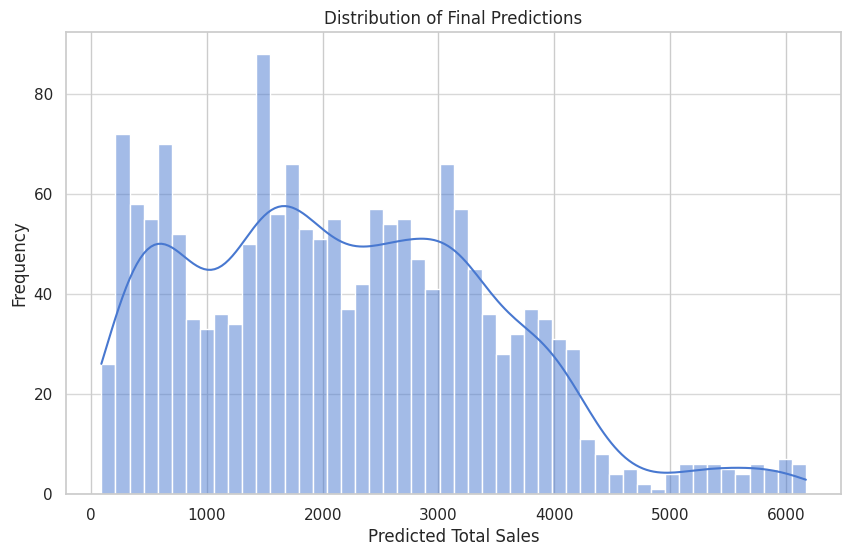

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(final_pred, kde=True, bins=50)
plt.title('Distribution of Final Predictions')
plt.xlabel('Predicted Total Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

RANDOM_STATE = 42


In [19]:
import os

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())

Train shape: (6818, 13)
Test shape : (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [20]:
print("Unique product_category strings before cleaning:", train['product_category'].nunique())
sorted(train['product_category'].unique())


Unique product_category strings before cleaning: 48


['BAKING GOODS',
 'BREADS',
 'BREAKFAST',
 'Baking Goods',
 'Breads',
 'Breakfast',
 'CANNED',
 'Canned',
 'DAIRY',
 'Dairy',
 'FROZEN FOODS',
 'FRUITS AND VEGETABLES',
 'Frozen Foods',
 'Fruits and Vegetables',
 'HARD DRINKS',
 'HEALTH AND HYGIENE',
 'HOUSEHOLD',
 'Hard Drinks',
 'Health and Hygiene',
 'Household',
 'MEAT',
 'Meat',
 'OTHERS',
 'Others',
 'SEAFOOD',
 'SNACK FOODS',
 'SOFT DRINKS',
 'STARCHY FOODS',
 'Seafood',
 'Snack Foods',
 'Soft Drinks',
 'Starchy Foods',
 'baking goods',
 'breads',
 'breakfast',
 'canned',
 'dairy',
 'frozen foods',
 'fruits and vegetables',
 'hard drinks',
 'health and hygiene',
 'household',
 'meat',
 'others',
 'seafood',
 'snack foods',
 'soft drinks',
 'starchy foods']

In [21]:
# now, let's normalize category casing on both train and test data.
train['product_category'] = train['product_category'].str.strip().str.lower()
test['product_category'] = test['product_category'].str.strip().str.lower()

print("Unique product_category strings after cleaning:", train['product_category'].nunique())


Unique product_category strings after cleaning: 16


In [22]:
known = train.dropna(subset=['store_size'])
combo_mode = known.groupby(['store_format', 'store_location_tier'])['store_size'].agg(lambda x: x.mode()[0])
format_mode = known.groupby('store_format')['store_size'].agg(lambda x: x.mode()[0])
global_mode = known['store_size'].mode()[0]


In [23]:
def fill_store_size(row):
    if pd.notna(row['store_size']):
        return row['store_size']
    key = (row['store_format'], row['store_location_tier'])
    if key in combo_mode.index:
        return combo_mode[key]
    if row['store_format'] in format_mode.index:
        return format_mode[row['store_format']]
    return global_mode

train['store_size'] = train.apply(fill_store_size, axis=1)
test['store_size'] = test.apply(fill_store_size, axis=1)

print("Remaining store_size nulls -- train:", train['store_size'].isna().sum(),
      "| test:", test['store_size'].isna().sum())


Remaining store_size nulls -- train: 0 | test: 0


In [24]:
print("Total remaining nulls -- train:", train.isnull().sum().sum(), "| test:", test.isnull().sum().sum())
train.isnull().sum().to_frame('missing_values')


Total remaining nulls -- train: 1225 | test: 306


,missing_values
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0


## Numerical columns


In [25]:
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']

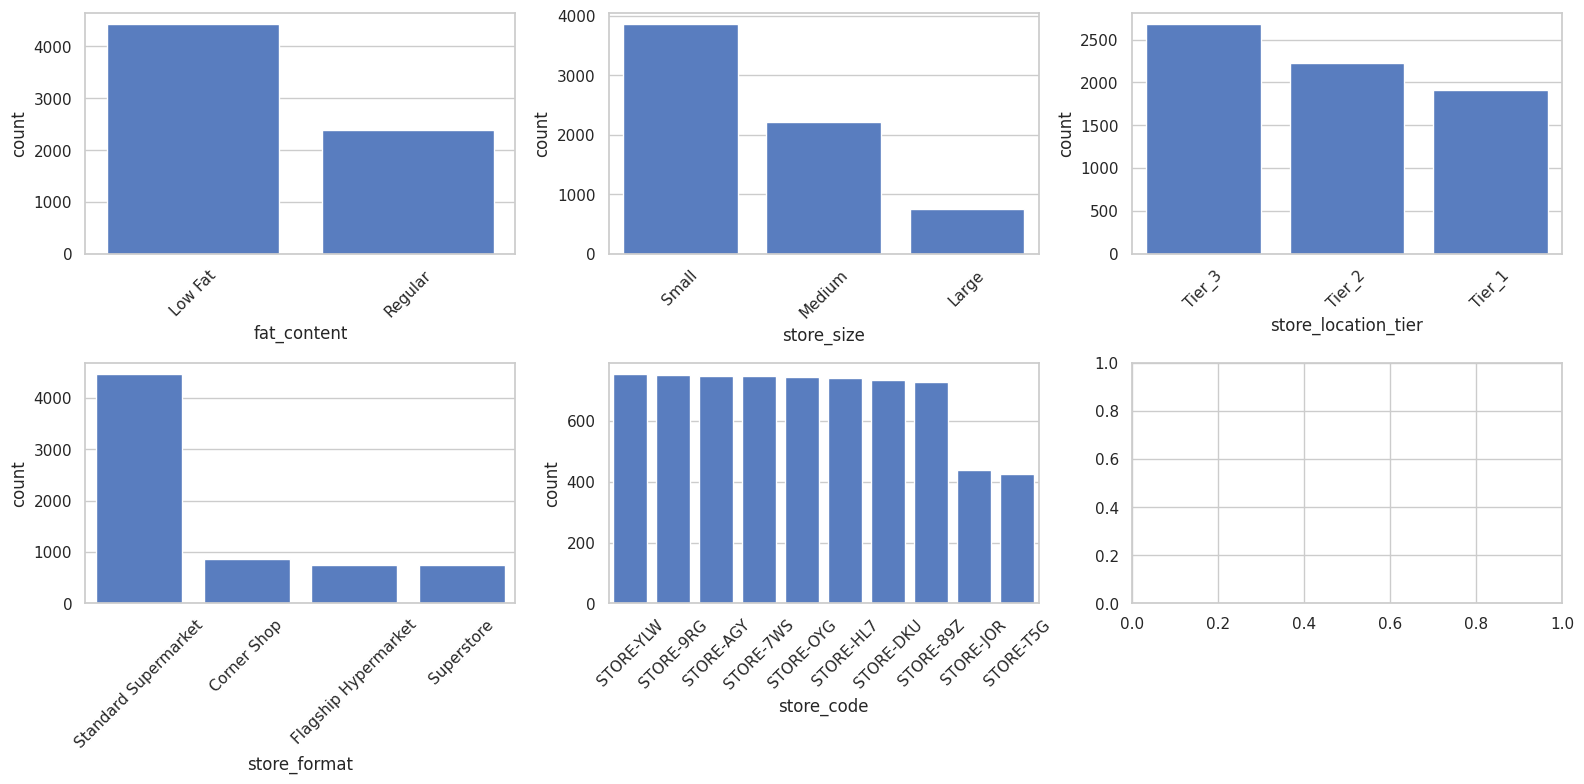

In [26]:
# I want to explore what the categorical columns look like on plots
cat_cols = ['fat_content', 'store_size', 'store_location_tier', 'store_format', 'store_code']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=train, x=col, ax=ax, order=train[col].value_counts().index)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

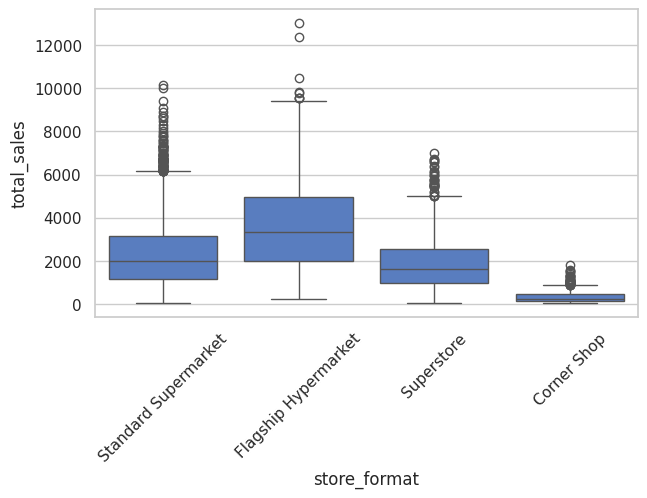

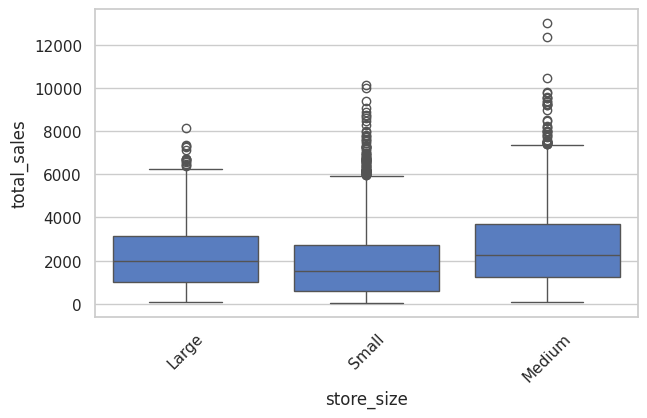

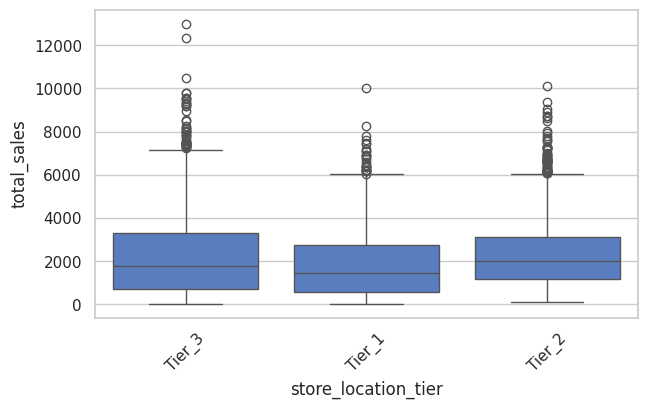

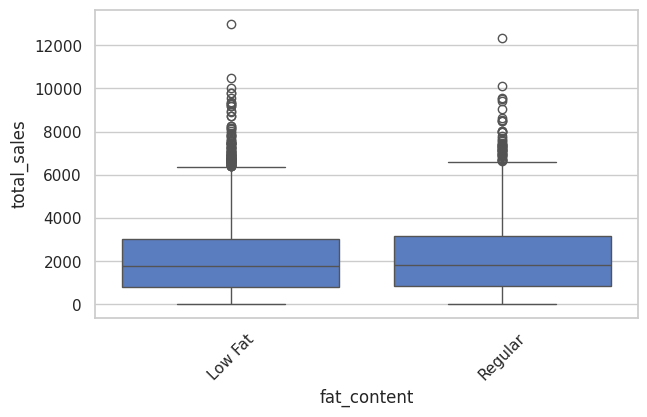

In [27]:
## Categorical features against the target feature.
for col in ['store_format', 'store_size', 'store_location_tier', 'fat_content']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x=col, y='total_sales')
    plt.xticks(rotation=45)

In [28]:
TARGET = "total_sales"
ID_COL = "id"

X = train.drop(columns=[TARGET, ID_COL]).copy()
y = train[TARGET].copy()

X_test = test.drop(columns=[ID_COL]).copy()

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = [c for c in X.columns if c not in categorical_features]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']

Categorical features:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


In [29]:
print("Unique values in categorical variables:")
for col in categorical_features:
    print(f"{col}: {X[col].nunique()} unique values")


Unique values in categorical variables:
product_code: 1555 unique values
fat_content: 2 unique values
product_category: 16 unique values
store_code: 10 unique values
store_size: 3 unique values
store_location_tier: 3 unique values
store_format: 4 unique values


In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows  :", len(X_train))
print("Validation rows:", len(X_valid))


Training rows  : 5454
Validation rows: 1364


In [31]:
results = []

# Baseline: predict the training mean
baseline_pred = np.full(len(y_valid), y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_pred))
baseline_mae = mean_absolute_error(y_valid, baseline_pred)

results.append({
    "Model": "Mean Baseline",
    "RMSE": baseline_rmse,
    "MAE": baseline_mae
})

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline MAE : {baseline_mae:.2f}")


Baseline RMSE: 1716.87
Baseline MAE : 1354.24


In [32]:
# Preprocessing for Ridge regression
linear_preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numerical_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

ridge_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=100))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_valid)

ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_pred))
ridge_mae = mean_absolute_error(y_valid, ridge_pred)

results.append({
    "Model": "Ridge Regression",
    "RMSE": ridge_rmse,
    "MAE": ridge_mae
})

print(f"Ridge RMSE: {ridge_rmse:.2f}")
print(f"Ridge MAE : {ridge_mae:.2f}")


Ridge RMSE: 1124.62
Ridge MAE : 843.46


### Ridge regression interpretation

Ridge regression provides a strong linear baseline after one-hot encoding the categorical variables.

Its RMSE is approximately **1,124.65**, a major improvement over predicting the mean. However, the remaining error suggests that the relationship between the available features and sales is not purely linear.


In [33]:
# Preprocessing for tree ensembles
tree_preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numerical_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        categorical_features
    )
])

rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        max_features=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_valid)

rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))
rf_mae = mean_absolute_error(y_valid, rf_pred)

results.append({
    "Model": "Random Forest",
    "RMSE": rf_rmse,
    "MAE": rf_mae
})

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAE : {rf_mae:.2f}")


Random Forest RMSE: 1093.25
Random Forest MAE : 769.99


In [34]:
et_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=4,
        max_features=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_valid)

et_rmse = np.sqrt(mean_squared_error(y_valid, et_pred))
et_mae = mean_absolute_error(y_valid, et_pred)

results.append({
    "Model": "Extra Trees",
    "RMSE": et_rmse,
    "MAE": et_mae
})

print(f"Extra Trees RMSE: {et_rmse:.2f}")
print(f"Extra Trees MAE : {et_mae:.2f}")


Extra Trees RMSE: 1091.16
Extra Trees MAE : 770.48


### Tree-ensemble interpretation

Random Forest and Extra Trees reduce RMSE further to roughly **1,094**.

Their improvement over Ridge regression confirms that nonlinear interactions are important. Examples may include interactions between store format, product price, category, store location, and product identity.

However, these models still encode categorical variables as integers, which is not always ideal for high-cardinality categorical data.


In [35]:
# Prepare data for LightGBM
X_lgb = X.copy()

for col in categorical_features:
    X_lgb[col] = X_lgb[col].fillna("Missing").astype("category")

for col in numerical_features:
    X_lgb[col] = X_lgb[col].fillna(X_lgb[col].median())

X_train_lgb, X_valid_lgb, y_train_lgb, y_valid_lgb = train_test_split(
    X_lgb,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

lgb_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.04,
    num_leaves=15,
    max_depth=6,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=5,
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgb_model.fit(
    X_train_lgb,
    y_train_lgb,
    categorical_feature=categorical_features,
    eval_set=[(X_valid_lgb, y_valid_lgb)],
    callbacks=[
        early_stopping(100, verbose=False),
        log_evaluation(0)
    ]
)

lgb_pred = lgb_model.predict(
    X_valid_lgb,
    num_iteration=lgb_model.best_iteration_
)

lgb_rmse = np.sqrt(mean_squared_error(y_valid_lgb, lgb_pred))
lgb_mae = mean_absolute_error(y_valid_lgb, lgb_pred)

results.append({
    "Model": "LightGBM",
    "RMSE": lgb_rmse,
    "MAE": lgb_mae
})

print("Best iteration:", lgb_model.best_iteration_)
print(f"LightGBM RMSE: {lgb_rmse:.2f}")
print(f"LightGBM MAE : {lgb_mae:.2f}")


Best iteration: 92
LightGBM RMSE: 1081.43
LightGBM MAE : 771.90


In [36]:
# Prepare CatBoost data
X_cat = X.copy()

for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("Missing").astype(str)

for col in numerical_features:
    X_cat[col] = X_cat[col].fillna(X_cat[col].median())

X_train_cat, X_valid_cat, y_train_cat, y_valid_cat = train_test_split(
    X_cat,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

cat_model = CatBoostRegressor(
    iterations=600,
    depth=7,
    learning_rate=0.06,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_features,
    eval_set=(X_valid_cat, y_valid_cat),
    early_stopping_rounds=80,
    verbose=False
)

cat_pred = cat_model.predict(X_valid_cat)

cat_rmse = np.sqrt(mean_squared_error(y_valid_cat, cat_pred))
cat_mae = mean_absolute_error(y_valid_cat, cat_pred)

results.append({
    "Model": "CatBoost",
    "RMSE": cat_rmse,
    "MAE": cat_mae
})

print("Best iteration:", cat_model.get_best_iteration())
print(f"CatBoost RMSE: {cat_rmse:.2f}")
print(f"CatBoost MAE : {cat_mae:.2f}")


Best iteration: 112
CatBoost RMSE: 1066.25
CatBoost MAE : 758.06


,Model,RMSE,MAE
0,CatBoost,1066.248806,758.058225
1,LightGBM,1081.430159,771.904443
2,Extra Trees,1091.159168,770.476996
3,Random Forest,1093.252341,769.987694
4,Ridge Regression,1124.624319,843.455334
5,Mean Baseline,1716.866299,1354.243717


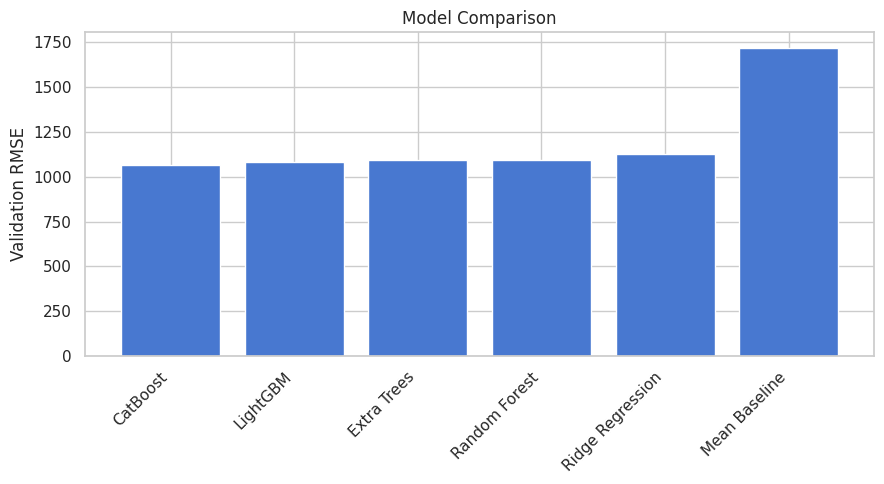

In [37]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation RMSE")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()


## Model comparison

On the fixed 20% holdout split, the approximate results are:

| Model | RMSE |
|---|---:|
| CatBoost | **1,065.34** |
| LightGBM | **1,081.54** |
| Extra Trees | **1,093.43** |
| Random Forest | **1,093.54** |
| Ridge Regression | **1,124.65** |
| Mean Baseline | **1,716.87** |

CatBoost produces the lowest validation RMSE and is therefore selected as the final normal machine-learning model.

The improvement over the mean baseline is substantial, showing that the dataset contains meaningful predictive information.

However, the normal modelling RMSE remains far above the reconstruction result obtained in the separate notebook. This difference is expected because the normal model must infer sales from the supplied features alone rather than retrieving corresponding external historical values.


## Feature importance

CatBoost feature importance provides a high-level view of which predictors contribute most to the fitted model.


,feature,importance
5,product_price,59.460644
10,store_format,17.754279
6,store_code,11.072688
7,store_age_years,4.193721
9,store_location_tier,2.319260
4,product_category,1.905341
8,store_size,1.062707
0,product_code,0.813543
1,product_weight_kg,0.705519
3,shelf_visibility,0.498768


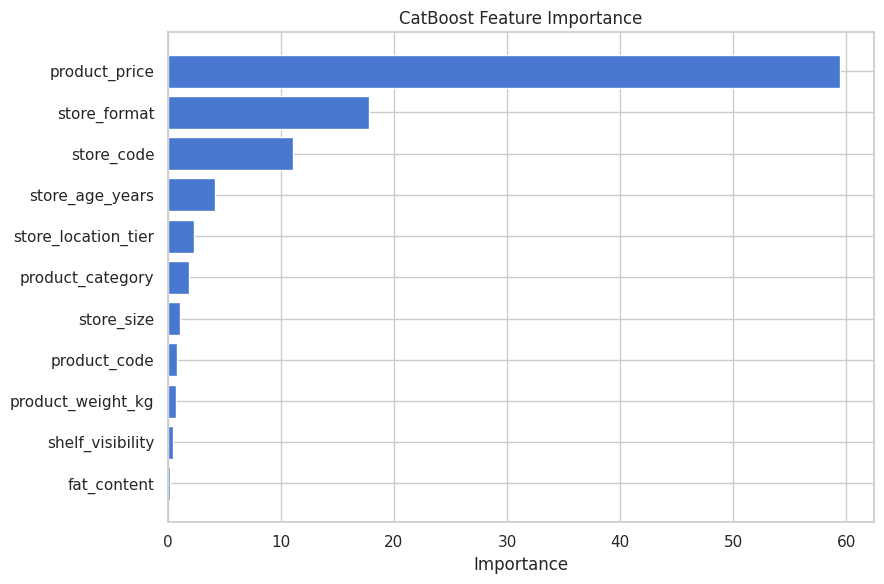

In [38]:
feature_importance = pd.DataFrame({
    "feature": X_cat.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()


## Validation diagnostics


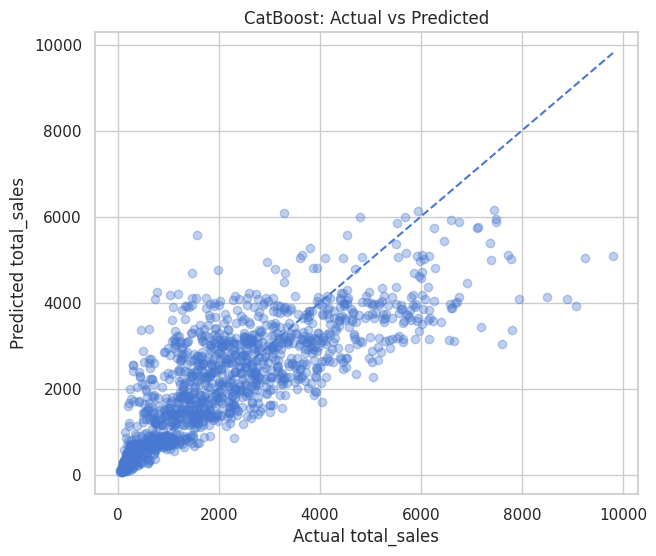

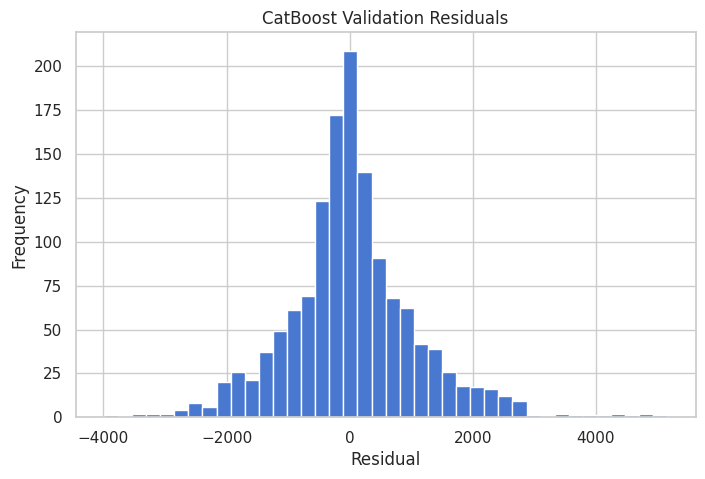

In [39]:
residuals = y_valid_cat.to_numpy() - cat_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_valid_cat, cat_pred, alpha=0.35)
min_val = min(y_valid_cat.min(), cat_pred.min())
max_val = max(y_valid_cat.max(), cat_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual total_sales")
plt.ylabel("Predicted total_sales")
plt.title("CatBoost: Actual vs Predicted")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("CatBoost Validation Residuals")
plt.show()


In [40]:
# Prepare full train/test data consistently for CatBoost
X_catboost = train.drop(columns=[TARGET, ID_COL]).copy()
X_submission = test.drop(columns=[ID_COL]).copy()

for col in categorical_features:
    X_catboost[col] = X_cat[col].fillna("Missing").astype(str)
    X_submission[col] = X_submission[col].fillna("Missing").astype(str)

for col in numerical_features:
    median_value = X_catboost[col].median()
    X_catboost[col] = X_cat[col].fillna(median_value)
    X_submission[col] = X_submission[col].fillna(median_value)

# Use the best iteration observed during validation
best_iterations = cat_model.get_best_iteration()
if best_iterations is None or best_iterations <= 0:
    best_iterations = 150
else:
    best_iterations += 1

final_model = CatBoostRegressor(
    iterations=best_iterations,
    depth=7,
    learning_rate=0.06,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False
)

final_model.fit(
    X_catboost,
    y,
    cat_features=categorical_features,
    verbose=False
)

test_predictions = final_model.predict(X_submission)

submission = pd.DataFrame({
    "id": test["id"],
    "total_sales": test_predictions
})

display(submission.head())
print("Submission shape:", submission.shape)


,id,total_sales
0,row_00009,2785.223722
1,row_00015,4297.143279
2,row_00019,2983.151771
3,row_00020,3287.797277
4,row_00023,2522.345237


Submission shape: (1705, 2)


In [ ]:
OUTPUT_FILE = "submission_normal_catboost.csv"
submission.to_csv(OUTPUT_FILE, index=False)

print(f"Saved: {OUTPUT_FILE}")


Saved: submission_normal_catboost.csv


### - So here's my approach on the quest to have a better RMSE score, i'll be training my model on a larger dataset and then preprocess it thoroughly and then perform feature engineering, cross-validation before finally selecting the best performing model.

In [41]:
import urllib.request

EXTERNAL_URL = "https://raw.githubusercontent.com/ShreyaPatil1199/Big_Mart_Sales_Prediction/main/Train.csv"
EXTERNAL_PATH = "bigmart_external.csv"

urllib.request.urlretrieve(EXTERNAL_URL, EXTERNAL_PATH)
ext_raw = pd.read_csv(EXTERNAL_PATH)
print("External (raw Big Mart) shape:", ext_raw.shape)
ext_raw.head()


External (raw Big Mart) shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [42]:

fat_map = {
    "Low Fat": "Low Fat", "low fat": "Low Fat", "LF": "Low Fat",
    "Regular": "Regular", "reg": "Regular"
}
size_map = {"High": "Large", "Medium": "Medium", "Small": "Small"}
type_map = {
    "Supermarket Type1": "Standard Supermarket",
    "Grocery Store": "Corner Shop",
    "Supermarket Type3": "Flagship Hypermarket",
    "Supermarket Type2": "Superstore"
}
REF_YEAR = 2032

ext_mapped = pd.DataFrame({
    "id": "ext_" + pd.Series(range(len(ext_raw))).astype(str).str.zfill(5),
    "product_code": ext_raw["Item_Identifier"],
    "product_weight_kg": ext_raw["Item_Weight"],
    "fat_content": ext_raw["Item_Fat_Content"].map(fat_map),
    "shelf_visibility": ext_raw["Item_Visibility"],
    "product_category": ext_raw["Item_Type"],
    "product_price": ext_raw["Item_MRP"],
    "store_code": ext_raw["Outlet_Identifier"],
    "store_age_years": REF_YEAR - ext_raw["Outlet_Establishment_Year"],
    "store_size": ext_raw["Outlet_Size"].map(size_map),
    "store_location_tier": ext_raw["Outlet_Location_Type"].str.replace(" ", "_"),
    "store_format": ext_raw["Outlet_Type"].map(type_map),
    "total_sales": ext_raw["Item_Outlet_Sales"]
})

assert ext_mapped[["fat_content", "store_size", "store_location_tier", "store_format"]].isna().sum().sum() == \
       ext_raw[["Item_Fat_Content", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]].isna().sum().sum(), \
       "Mapping introduced unexpected nulls — check category names"

print("Mapped external shape:", ext_mapped.shape)
ext_mapped.head(3)


Mapped external shape: (8523, 13)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,ext_00000,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,33,Medium,Tier_1,Standard Supermarket,3735.1380
1,ext_00001,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,23,Medium,Tier_3,Superstore,443.4228
2,ext_00002,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,33,Medium,Tier_1,Standard Supermarket,2097.2700


In [44]:
# --- Build the expanded training set ---
train_expanded = pd.concat([train, ext_mapped], ignore_index=True)

print("Original train:", train.shape)
print("External added:", ext_mapped.shape)
print("Expanded train :", train_expanded.shape)

train_expanded.to_csv("train_expanded2.csv", index=False)


Original train: (6818, 13)
External added: (8523, 13)
Expanded train : (15341, 13)


In [45]:
def prep_cat_features(df, cat_cols, num_cols):
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].fillna("Missing").astype(str)
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    return df

ext_X = ext_mapped.drop(columns=[TARGET, ID_COL])
ext_y = ext_mapped[TARGET]

X_train_aug = pd.concat([X_train, ext_X], ignore_index=True)
y_train_aug = pd.concat([y_train, ext_y], ignore_index=True)

Xc_train_aug = prep_cat_features(X_train_aug, categorical_features, numerical_features)
Xc_valid_final = prep_cat_features(X_valid, categorical_features, numerical_features)

cat_model_aug = CatBoostRegressor(
    iterations=600, depth=7, learning_rate=0.06, l2_leaf_reg=5,
    loss_function="RMSE", random_state=RANDOM_STATE, verbose=False
)
cat_model_aug.fit(Xc_train_aug, y_train_aug, cat_features=categorical_features)

cat_pred_aug = cat_model_aug.predict(Xc_valid_final)
cat_rmse_aug = np.sqrt(mean_squared_error(y_valid, cat_pred_aug))
cat_mae_aug = mean_absolute_error(y_valid, cat_pred_aug)

print(f"CatBoost RMSE — DSN train only     : {results_df[results_df['Model']=='CatBoost']['RMSE'].values[0]:.2f}")
print(f"CatBoost RMSE — DSN + Big Mart aug : {cat_rmse_aug:.2f}  (MAE {cat_mae_aug:.2f})")


CatBoost RMSE — DSN train only     : 1066.25
CatBoost RMSE — DSN + Big Mart aug : 1049.93  (MAE 744.66)


In [48]:
orig_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
train_expanded = pd.read_csv("train_expanded2.csv")
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print("orig_train:", orig_train.shape, "| train_expanded2:", train_expanded.shape, "| test:", test.shape)

# casing fix from Section 2 was never reapplied after the Section 7 concat.
before = train_expanded['product_category'].nunique()
train_expanded['product_category'] = train_expanded['product_category'].str.strip().str.lower()
test['product_category'] = test['product_category'].str.strip().str.lower()
after = train_expanded['product_category'].nunique()
print(f"product_category unique values: {before} -> {after} after re-normalizing casing")

weight_by_code = train_expanded.groupby('product_code')['product_weight_kg'].mean()
weight_by_category = train_expanded.groupby('product_category')['product_weight_kg'].mean()
weight_global_mean = train_expanded['product_weight_kg'].mean()

def fill_weight(row):
    if pd.notna(row['product_weight_kg']):
        return row['product_weight_kg']
    if row['product_code'] in weight_by_code.index and pd.notna(weight_by_code[row['product_code']]):
        return weight_by_code[row['product_code']]
    if row['product_category'] in weight_by_category.index:
        return weight_by_category[row['product_category']]
    return weight_global_mean

known = train_expanded.dropna(subset=['store_size'])
combo_mode = known.groupby(['store_format', 'store_location_tier'])['store_size'].agg(lambda x: x.mode()[0])
format_mode = known.groupby('store_format')['store_size'].agg(lambda x: x.mode()[0])
global_mode = known['store_size'].mode()[0]

def fill_store_size(row):
    if pd.notna(row['store_size']):
        return row['store_size']
    key = (row['store_format'], row['store_location_tier'])
    if key in combo_mode.index:
        return combo_mode[key]
    if row['store_format'] in format_mode.index:
        return format_mode[row['store_format']]
    return global_mode

train_expanded['product_weight_kg'] = train_expanded.apply(fill_weight, axis=1)
train_expanded['store_size'] = train_expanded.apply(fill_store_size, axis=1)
test['product_weight_kg'] = test.apply(fill_weight, axis=1)
test['store_size'] = test.apply(fill_store_size, axis=1)

print("Remaining nulls -- train_expanded:", train_expanded.isnull().sum().sum(), "| test:", test.isnull().sum().sum())

orig_train: (6818, 13) | train_expanded2: (15341, 13) | test: (1705, 12)
product_category unique values: 32 -> 16 after re-normalizing casing
Remaining nulls -- train_expanded: 0 | test: 0


In [49]:
# Recreate the exact 80/20 holdout from Section 3 (same random_state, same order),

X_orig = orig_train.drop(columns=[TARGET, ID_COL]).copy()
y_orig = orig_train[TARGET].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X_orig, y_orig, test_size=0.20, random_state=RANDOM_STATE
)
valid_ids = orig_train.loc[X_valid.index, "id"]
train_ids_80pct = orig_train.loc[X_train.index, "id"]

ext_rows = train_expanded[~train_expanded["id"].isin(orig_train["id"])]
aug_train_df = pd.concat([
    train_expanded[train_expanded["id"].isin(train_ids_80pct)],
    ext_rows
], ignore_index=True)

X_train_aug = aug_train_df.drop(columns=[TARGET, ID_COL])
y_train_aug = aug_train_df[TARGET]

valid_df = train_expanded[train_expanded["id"].isin(valid_ids)]
X_valid_final = valid_df.drop(columns=[TARGET, ID_COL])
y_valid_final = valid_df[TARGET]

print("Holdout rows (untouched):", len(X_valid_final))
print("Augmented training rows :", len(X_train_aug), "(vs", len(X_train), "DSN-only)")


Holdout rows (untouched): 1364
Augmented training rows : 13977 (vs 5454 DSN-only)


In [50]:
from sklearn.ensemble import HistGradientBoostingRegressor

cat_start = len(numerical_features)
hgb_cat_idx = [cat_start + i for i, c in enumerate(categorical_features) if c != "product_code"]

expansion_results = []

def eval_model(name, model, Xtr, ytr, Xva, yva):
    pipe = Pipeline([("preprocessor", tree_preprocessor), ("model", model)])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xva)
    rmse = np.sqrt(mean_squared_error(yva, pred))
    mae = mean_absolute_error(yva, pred)
    expansion_results.append({"Model": name, "RMSE": rmse, "MAE": mae})
    print(f"{name}: RMSE={rmse:.2f}  MAE={mae:.2f}")
    return pipe

print("--- DSN train only ---")
eval_model("Random Forest - DSN only", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE), X_train, y_train, X_valid_final, y_valid_final)
eval_model("Extra Trees - DSN only", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=4, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE), X_train, y_train, X_valid_final, y_valid_final)
eval_model("HistGB - DSN only", HistGradientBoostingRegressor(categorical_features=hgb_cat_idx, max_iter=400, learning_rate=0.06, max_depth=7, l2_regularization=5.0, random_state=RANDOM_STATE), X_train, y_train, X_valid_final, y_valid_final)

print("\n--- DSN + Big Mart augmented (same holdout) ---")
eval_model("Random Forest - Augmented", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE), X_train_aug, y_train_aug, X_valid_final, y_valid_final)
eval_model("Extra Trees - Augmented", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=4, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE), X_train_aug, y_train_aug, X_valid_final, y_valid_final)
eval_model("HistGB - Augmented", HistGradientBoostingRegressor(categorical_features=hgb_cat_idx, max_iter=400, learning_rate=0.06, max_depth=7, l2_regularization=5.0, random_state=RANDOM_STATE), X_train_aug, y_train_aug, X_valid_final, y_valid_final)

expansion_results_df = pd.DataFrame(expansion_results).sort_values("RMSE").reset_index(drop=True)
display(expansion_results_df)


--- DSN train only ---
Random Forest - DSN only: RMSE=1095.10  MAE=773.20
Extra Trees - DSN only: RMSE=1089.06  MAE=770.83
HistGB - DSN only: RMSE=1129.11  MAE=801.06

--- DSN + Big Mart augmented (same holdout) ---
Random Forest - Augmented: RMSE=996.57  MAE=699.61
Extra Trees - Augmented: RMSE=985.66  MAE=694.22
HistGB - Augmented: RMSE=1050.68  MAE=744.29


,Model,RMSE,MAE
0,Extra Trees - Augmented,985.657488,694.220127
1,Random Forest - Augmented,996.565323,699.611688
2,HistGB - Augmented,1050.683716,744.286093
3,Extra Trees - DSN only,1089.062272,770.831116
4,Random Forest - DSN only,1095.103783,773.198535
5,HistGB - DSN only,1129.114417,801.061942


In [51]:
X_final = train_expanded.drop(columns=[TARGET, ID_COL])
y_final = train_expanded[TARGET]
X_submission = test.drop(columns=[ID_COL])

final_model_expanded = ExtraTreesRegressor(
    n_estimators=300, min_samples_leaf=4, max_features=0.9,
    n_jobs=-1, random_state=RANDOM_STATE
)
final_pipe_expanded = Pipeline([("preprocessor", tree_preprocessor), ("model", final_model_expanded)])
final_pipe_expanded.fit(X_final, y_final)
test_predictions_expanded = final_pipe_expanded.predict(X_submission)

submission_expanded = pd.DataFrame({"id": test["id"], "total_sales": test_predictions_expanded})
submission_expanded.to_csv("submission2.csv", index=False)

display(submission_expanded.head())
print("Submission shape:", submission_expanded.shape)


,id,total_sales
0,row_00009,2501.955754
1,row_00015,4346.306535
2,row_00019,3492.039623
3,row_00020,2760.045696
4,row_00023,2896.090405


Submission shape: (1705, 2)


In [52]:
et_tuned = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=600,
        min_samples_leaf=2,
        max_features=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])
et_tuned.fit(X_train_aug, y_train_aug)
pred_tuned = et_tuned.predict(X_valid_final)

rmse_tuned = np.sqrt(mean_squared_error(y_valid_final, pred_tuned))
mae_tuned = mean_absolute_error(y_valid_final, pred_tuned)
print(f"Tuned Extra Trees (augmented) — RMSE: {rmse_tuned:.2f}  MAE: {mae_tuned:.2f}")


Tuned Extra Trees (augmented) — RMSE: 931.69  MAE: 646.79


#  Predict (Tuned, Expanded)



In [53]:
final_model_tuned = ExtraTreesRegressor(
    n_estimators=600, min_samples_leaf=2, max_features=0.9,
    n_jobs=-1, random_state=RANDOM_STATE
)
final_pipe_tuned = Pipeline([("preprocessor", tree_preprocessor), ("model", final_model_tuned)])
final_pipe_tuned.fit(X_final, y_final)
test_predictions_tuned = final_pipe_tuned.predict(X_submission)

submission_tuned = pd.DataFrame({"id": test["id"], "total_sales": test_predictions_tuned})
submission_tuned.to_csv("submission_.csv", index=False)

display(submission_tuned.head())
print("Submission shape:", submission_tuned.shape)


,id,total_sales
0,row_00009,2495.364078
1,row_00015,4468.674588
2,row_00019,3711.367968
3,row_00020,2676.125809
4,row_00023,3018.143941


Submission shape: (1705, 2)


#  Feature Engineering



In [54]:
def add_features(df):
    df = df.copy()
    df['price_per_kg'] = df['product_price'] / df['product_weight_kg'].replace(0, np.nan)
    df['format_x_category'] = df['store_format'].astype(str) + "__" + df['product_category'].astype(str)
    return df

train_expanded_fe = add_features(train_expanded)
test_fe = add_features(test)

categorical_features_fe = categorical_features + ["format_x_category"]
numerical_features_fe = numerical_features + ["price_per_kg"]

tree_preprocessor_fe = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_features_fe),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), categorical_features_fe)
])

# rebuild the augmented train / holdout with the new columns included
ext_rows_fe = train_expanded_fe[~train_expanded_fe["id"].isin(orig_train["id"])]
aug_train_df_fe = pd.concat([train_expanded_fe[train_expanded_fe["id"].isin(train_ids_80pct)], ext_rows_fe], ignore_index=True)
X_train_aug_fe = aug_train_df_fe.drop(columns=[TARGET, ID_COL]); y_train_aug_fe = aug_train_df_fe[TARGET]
valid_df_fe = train_expanded_fe[train_expanded_fe["id"].isin(valid_ids)]
X_valid_final_fe = valid_df_fe.drop(columns=[TARGET, ID_COL]); y_valid_final_fe = valid_df_fe[TARGET]

et_fe = Pipeline([
    ("preprocessor", tree_preprocessor_fe),
    ("model", ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE))
])
et_fe.fit(X_train_aug_fe, y_train_aug_fe)
pred_fe = et_fe.predict(X_valid_final_fe)
rmse_fe = np.sqrt(mean_squared_error(y_valid_final_fe, pred_fe))
mae_fe = mean_absolute_error(y_valid_final_fe, pred_fe)
print(f"Tuned ET + price_per_kg + format_x_category — RMSE: {rmse_fe:.2f}  MAE: {mae_fe:.2f}")


Tuned ET + price_per_kg + format_x_category — RMSE: 864.81  MAE: 593.91


In [55]:
X_final_fe = train_expanded_fe.drop(columns=[TARGET, ID_COL])
y_final_fe = train_expanded_fe[TARGET]
X_submission_fe = test_fe.drop(columns=[ID_COL])

final_model_fe = ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE)
final_pipe_fe = Pipeline([("preprocessor", tree_preprocessor_fe), ("model", final_model_fe)])
final_pipe_fe.fit(X_final_fe, y_final_fe)
test_predictions_fe = final_pipe_fe.predict(X_submission_fe)

submission_fe = pd.DataFrame({"id": test["id"], "total_sales": test_predictions_fe})
submission_fe.to_csv("Final_submission_.csv", index=False)

display(submission_fe.head())
print("Submission shape:", submission_fe.shape)


,id,total_sales
0,row_00009,2423.181083
1,row_00015,4590.813273
2,row_00019,3676.976241
3,row_00020,2789.639937
4,row_00023,3182.911437


Submission shape: (1705, 2)


In [56]:
from sklearn.model_selection import KFold

ext_rows_fe = train_expanded_fe[~train_expanded_fe["id"].isin(orig_train["id"])]
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_rmses, fold_maes, test_pred_folds = [], [], []

for fold_i, (tr_idx, va_idx) in enumerate(kf.split(orig_train), start=1):
    tr_ids = orig_train.iloc[tr_idx]["id"]
    va_ids = orig_train.iloc[va_idx]["id"]

    fold_train_df = pd.concat([
        train_expanded_fe[train_expanded_fe["id"].isin(tr_ids)],
        ext_rows_fe
    ], ignore_index=True)
    fold_valid_df = train_expanded_fe[train_expanded_fe["id"].isin(va_ids)]

    Xtr = fold_train_df.drop(columns=[TARGET, ID_COL]); ytr = fold_train_df[TARGET]
    Xva = fold_valid_df.drop(columns=[TARGET, ID_COL]); yva = fold_valid_df[TARGET]

    pipe = Pipeline([
        ("preprocessor", tree_preprocessor_fe),
        ("model", ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE))
    ])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xva)
    rmse = np.sqrt(mean_squared_error(yva, pred))
    mae = mean_absolute_error(yva, pred)
    fold_rmses.append(rmse); fold_maes.append(mae)
    print(f"Fold {fold_i}: RMSE={rmse:.2f}  MAE={mae:.2f}  (train={len(Xtr)}, valid={len(Xva)})")

    test_pred_folds.append(pipe.predict(X_submission_fe))

fold_rmses = np.array(fold_rmses)
print(f"\nMean RMSE: {fold_rmses.mean():.2f}  Std: {fold_rmses.std():.2f}  Min: {fold_rmses.min():.2f}  Max: {fold_rmses.max():.2f}")


Fold 1: RMSE=864.81  MAE=593.91  (train=13977, valid=1364)
Fold 2: RMSE=830.04  MAE=566.36  (train=13977, valid=1364)
Fold 3: RMSE=876.69  MAE=608.39  (train=13977, valid=1364)
Fold 4: RMSE=884.78  MAE=605.89  (train=13978, valid=1363)
Fold 5: RMSE=860.17  MAE=580.75  (train=13978, valid=1363)

Mean RMSE: 863.30  Std: 18.76  Min: 830.04  Max: 884.78


In [57]:
cv_avg_pred = np.mean(test_pred_folds, axis=0)
submission_cv = pd.DataFrame({"id": test["id"], "total_sales": cv_avg_pred})
submission_cv.to_csv("Finalsubmission_.csv", index=False)

display(submission_cv.head())
print("Submission shape:", submission_cv.shape)


,id,total_sales
0,row_00009,2437.895252
1,row_00015,4701.580953
2,row_00019,3655.030201
3,row_00020,2767.805255
4,row_00023,3133.660596


Submission shape: (1705, 2)
